In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as plt
import pickle 

In [2]:
# models
# Extra Trees (faster than RandomForest sometimes)
from sklearn.ensemble import ExtraTreesClassifier

# Linear models
from sklearn.linear_model import LogisticRegression,LinearRegression

# Tree-based
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor

# Ensemble models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier

# Support Vector Machine
from sklearn.svm import SVC

# Neighbors
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor

# Naive Bayes
from sklearn.naive_bayes import GaussianNB

In [3]:
data=pd.read_csv('wine-quality-white-and-red.csv')

In [4]:
data


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [5]:
data.columns

Index(['type', 'fixed acidity', 'volatile acidity', 'citric acid',
       'residual sugar', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'quality'],
      dtype='str')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   str    
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [7]:
data.isna().sum()

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(1177)

In [9]:
data.drop_duplicates(inplace=True,keep='first')

In [10]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000
mean,7.215179,0.344130,0.318494,5.048477,0.056690,30.036654,114.109023,0.994535,3.224664,0.533357,10.549241,5.795677
std,1.319671,0.168248,0.147157,4.500180,0.036863,17.805045,56.774223,0.002966,0.160379,0.149743,1.185933,0.879772
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994650,3.210000,0.510000,10.400000,6.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.250000,0.996770,3.330000,0.600000,11.400000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [11]:
data

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
6,white,6.2,0.320,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6491,red,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [12]:
data.drop(columns=['free sulfur dioxide',],inplace=True)

In [13]:
Y=data[['type']]
X=data.drop(columns=['type'])

In [15]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.270,0.36,20.7,0.045,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.300,0.34,1.6,0.049,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.280,0.40,6.9,0.050,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.230,0.32,8.5,0.058,186.0,0.99560,3.19,0.40,9.9,6
6,6.2,0.320,0.16,7.0,0.045,136.0,0.99490,3.18,0.47,9.6,6
...,...,...,...,...,...,...,...,...,...,...,...
6491,6.8,0.620,0.08,1.9,0.068,38.0,0.99651,3.42,0.82,9.5,6
6492,6.2,0.600,0.08,2.0,0.090,44.0,0.99490,3.45,0.58,10.5,5
6493,5.9,0.550,0.10,2.2,0.062,51.0,0.99512,3.52,0.76,11.2,6
6495,5.9,0.645,0.12,2.0,0.075,44.0,0.99547,3.57,0.71,10.2,5


In [17]:
Y

,type
0,white
1,white
2,white
3,white
6,white
...,...
6491,red
6492,red
6493,red
6495,red


<Axes: >

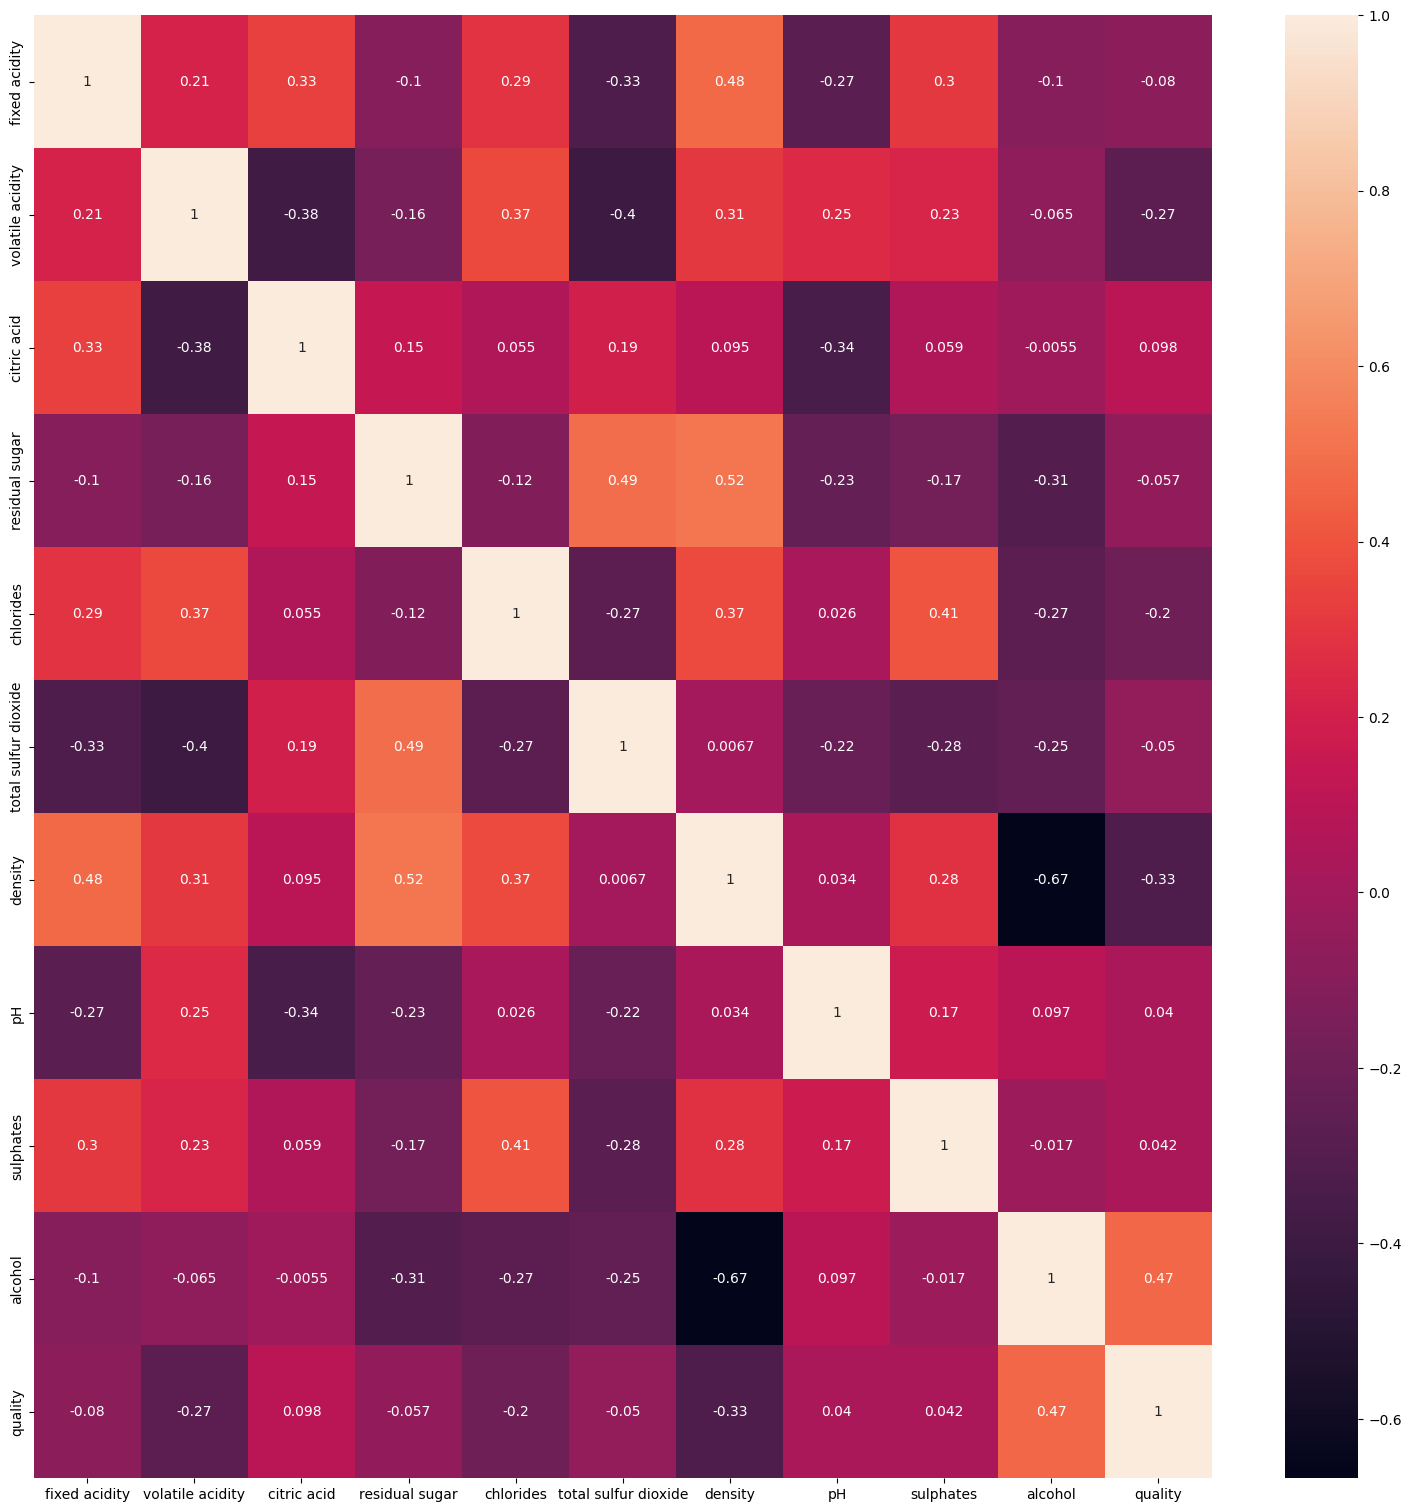

In [18]:
plt.figure(figsize=(19,19))
sns.heatmap(X.corr(),annot=True)

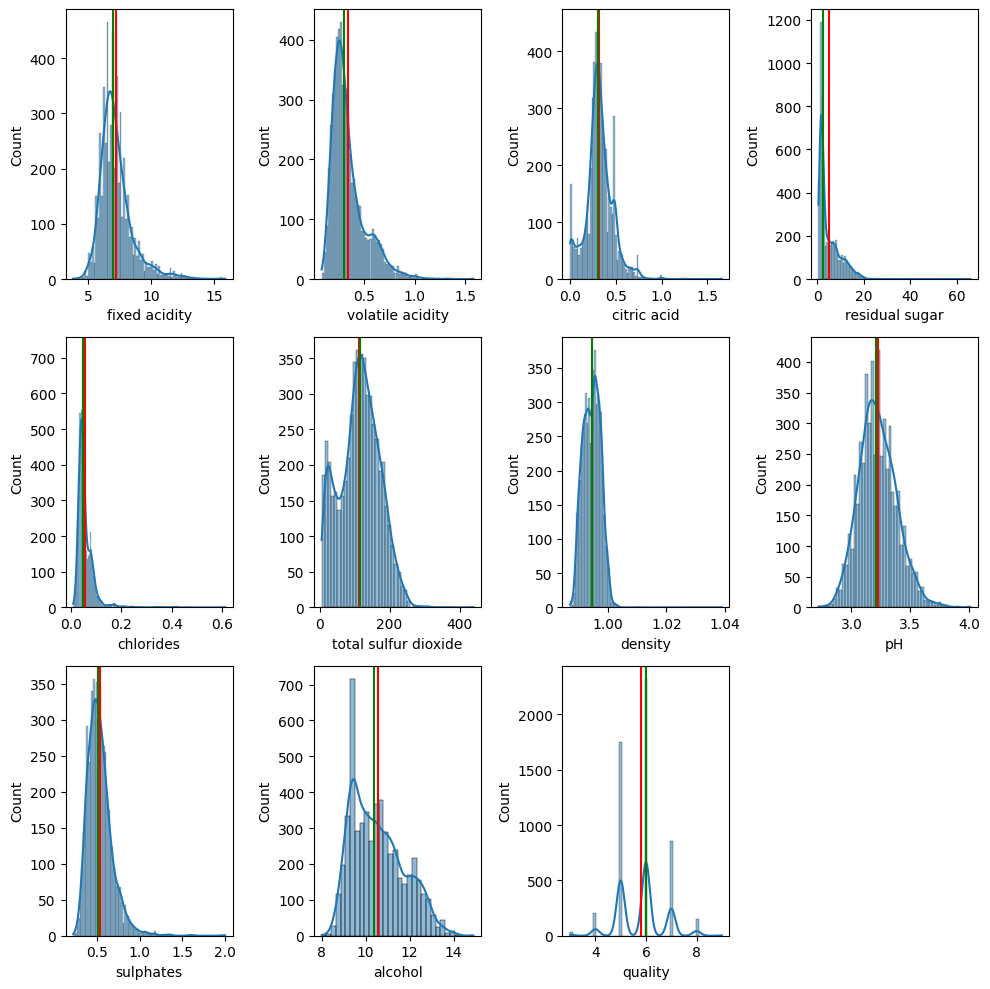

In [19]:
j=1
plt.figure(figsize=(10,10))
for i in data.select_dtypes(exclude=object):
    plt.subplot(3,4,j)
    sns.histplot(data[i],kde=True,)
    plt.axvline(data[i].mean(),color='r')
    plt.axvline(data[i].median(),color='g')
    j=j+1

plt.tight_layout()

In [20]:
# sns.pairplot(data,hue='type')

In [21]:
X.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'total sulfur dioxide', 'density', 'pH', 'sulphates',
       'alcohol', 'quality'],
      dtype='str')

In [22]:
data.select_dtypes(exclude=object).skew()

fixed acidity           1.650417
volatile acidity        1.504557
citric acid             0.484309
residual sugar          1.706550
chlorides               5.338237
total sulfur dioxide    0.063614
density                 0.666326
pH                      0.389969
sulphates               1.809454
alcohol                 0.545696
quality                 0.147467
dtype: float64

In [23]:
Y_encoded=Y['type'].map({'red':1,"white":0})

In [24]:
Y_encoded

0       0
1       0
2       0
3       0
6       0
       ..
6491    1
6492    1
6493    1
6495    1
6496    1
Name: type, Length: 5320, dtype: int64

In [25]:
x_train,x_test,y_train,y_test=train_test_split(X,Y_encoded,train_size=0.80,random_state=1)



In [26]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)

In [27]:
x_test_scaled=scaler.transform(x_test)

In [30]:
x_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,total sulfur dioxide,density,pH,sulphates,alcohol,quality
906,8.3,0.270,0.45,1.3,0.048,72.0,0.99440,3.08,0.61,10.3,4
2096,6.8,0.320,0.34,6.0,0.050,129.0,0.99530,3.19,0.40,9.1,5
711,8.2,0.270,0.43,1.6,0.035,128.0,0.99160,3.10,0.50,12.3,6
3681,7.0,0.220,0.26,9.2,0.027,122.0,0.99228,3.06,0.34,12.5,8
432,7.4,0.155,0.34,2.3,0.045,214.0,0.99340,3.18,0.61,9.9,7
...,...,...,...,...,...,...,...,...,...,...,...
1070,8.0,0.370,0.32,1.6,0.040,166.0,0.99200,3.00,0.55,11.3,7
6350,6.6,0.580,0.02,2.0,0.062,53.0,0.99374,3.35,0.76,11.6,7
4919,7.6,0.390,0.31,2.3,0.082,71.0,0.99820,3.52,0.65,9.7,5
278,6.8,0.320,0.34,1.2,0.044,67.0,0.99190,3.05,0.47,10.6,4


In [28]:
models = {
    "Logistic": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Extra Trees":ExtraTreesClassifier(),
    'AdaBoost':AdaBoostClassifier()
}

In [27]:
for name,model in models.items():
    model.fit(x_train_scaled,y_train)
    y_pred=model.predict(x_test_scaled)

    print(name)
    print(confusion_matrix(y_pred=y_pred,y_true=y_test))
    print(classification_report(y_pred=y_pred,y_true=y_test))
    

Logistic
[[790   2]
 [  1 271]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       792
           1       0.99      1.00      0.99       272

    accuracy                           1.00      1064
   macro avg       1.00      1.00      1.00      1064
weighted avg       1.00      1.00      1.00      1064

Decision Tree
[[781  11]
 [ 10 262]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       792
           1       0.96      0.96      0.96       272

    accuracy                           0.98      1064
   macro avg       0.97      0.97      0.97      1064
weighted avg       0.98      0.98      0.98      1064

Random Forest
[[790   2]
 [  3 269]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       792
           1       0.99      0.99      0.99       272

    accuracy                           1.00      1064
   macro avg       0.9

In [28]:
model=SVC()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)

print(name)
print(confusion_matrix(y_pred=y_pred,y_true=y_test))
print(classification_report(y_pred=y_pred,y_true=y_test))

AdaBoost
[[792   0]
 [  1 271]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       792
           1       1.00      1.00      1.00       272

    accuracy                           1.00      1064
   macro avg       1.00      1.00      1.00      1064
weighted avg       1.00      1.00      1.00      1064



In [29]:
pickle.dump(model,open('model.pkl','wb'))

In [30]:
pickle.dump(scaler,open('scaler.pkl','wb'))

In [31]:
from sklearn.metrics import r2_score,f1_score
f1_score(y_pred=y_pred,y_true=y_test,labels=[1])


0.998158379373849

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_classification_model(x_train, x_test, y_train, y_test, models):
    try:
        report = {}

        classes = sorted(set(y_test))

        for name, model in models.items():
            model.fit(x_train, y_train)
            y_pred = model.predict(x_test)

            acc = accuracy_score(y_test, y_pred)
            f1_vals = f1_score(y_test, y_pred, average=None)
            report[name] = {
                "accuracy": acc,
                "f1_per_class": f1_vals
            }

        return report

    except Exception as e:
      pass

In [33]:
evaluate_classification_model(x_train_scaled,x_test_scaled,y_train,y_test,models)

{'Logistic': {'accuracy': 0.9971804511278195,
  'f1_per_class': {0: np.float64(0.998104864181933),
   1: np.float64(0.9944954128440368)}},
 'Decision Tree': {'accuracy': 0.9783834586466166,
  'f1_per_class': {0: np.float64(0.9854522454142948),
   1: np.float64(0.9579524680073126)}},
 'Random Forest': {'accuracy': 0.9943609022556391,
  'f1_per_class': {0: np.float64(0.9962168978562421),
   1: np.float64(0.988929889298893)}},
 'Gradient Boosting': {'accuracy': 0.9924812030075187,
  'f1_per_class': {0: np.float64(0.9949494949494949),
   1: np.float64(0.9852941176470589)}},
 'SVM': {'accuracy': 0.9990601503759399,
  'f1_per_class': {0: np.float64(0.9993690851735015),
   1: np.float64(0.998158379373849)}},
 'KNN': {'accuracy': 0.9953007518796992,
  'f1_per_class': {0: np.float64(0.9968454258675079),
   1: np.float64(0.990791896869245)}},
 'Naive Bayes': {'accuracy': 0.9736842105263158,
  'f1_per_class': {0: np.float64(0.9821882951653944),
   1: np.float64(0.9496402877697842)}},
 'Extra Tree

In [59]:
model_report:dict=evaluate_classification_model(x_train_scaled,x_test_scaled,y_train,y_test,models)

In [62]:
(model_report.values())

dict_values([{'accuracy': 0.9971804511278195, 'f1_per_class': {0: np.float64(0.998104864181933), 1: np.float64(0.9944954128440368)}}, {'accuracy': 0.9830827067669173, 'f1_per_class': {0: np.float64(0.9886506935687264), 1: np.float64(0.966789667896679)}}, {'accuracy': 0.9953007518796992, 'f1_per_class': {0: np.float64(0.9968494013862634), 1: np.float64(0.9907578558225508)}}, {'accuracy': 0.9924812030075187, 'f1_per_class': {0: np.float64(0.9949494949494949), 1: np.float64(0.9852941176470589)}}, {'accuracy': 0.9990601503759399, 'f1_per_class': {0: np.float64(0.9993690851735015), 1: np.float64(0.998158379373849)}}, {'accuracy': 0.9953007518796992, 'f1_per_class': {0: np.float64(0.9968454258675079), 1: np.float64(0.990791896869245)}}, {'accuracy': 0.9736842105263158, 'f1_per_class': {0: np.float64(0.9821882951653944), 1: np.float64(0.9496402877697842)}}, {'accuracy': 0.9962406015037594, 'f1_per_class': {0: np.float64(0.9974747474747475), 1: np.float64(0.9926470588235294)}}, {'accuracy': 0.

In [36]:
data=pd.DataFrame({'h':[163, 171, 185, 168, 190, 177, 162, 188, 174, 181],
                    'w':[62, 75, 89, 94, 68, 100, 83, 71, 97, 66]})

In [37]:
data

,h,w
0,163,62
1,171,75
2,185,89
3,168,94
4,190,68
5,177,100
6,162,83
7,188,71
8,174,97
9,181,66


In [39]:
mods={
    "linear": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    'KNeighborsRegressor':KNeighborsRegressor(),
}

In [51]:
x_T,x_t,y_T,y_t=train_test_split(data[['w']],data[['h']],random_state=42,test_size=0.2)

In [53]:
def evaluate_model(x_train,x_test,y_train,y_test,models):
    try:
        report={}
        for i in range(len(list(models))):
            model=list(models.values())[i]
            model.fit(x_train,y_train)
            
            y_pred=model.predict(x_test)
            R2=r2_score(y_pred=y_pred,y_true=y_test)
            
            report[list(models.keys())[i]]=R2
        return report
    except Exception as e:
        raise(e)
evaluate_model(x_T,x_t,y_T,y_t,mods)

{'linear': -7.700282950103274,
 'Decision Tree': -71.22222222222223,
 'KNeighborsRegressor': -7.364444444444473}

In [58]:

model_report:dict=evaluate_model(x_T,x_t,y_T,y_t,mods)
print(max(sorted(model_report.values())))
# print(best_model_score=list(model_report.keys())[list(model_report.values()).index(best_model_score)])

-7.364444444444473


In [64]:
f1_score(y_pred=y_pred,y_true=y_test,average='weighted')

0.9990595814352445